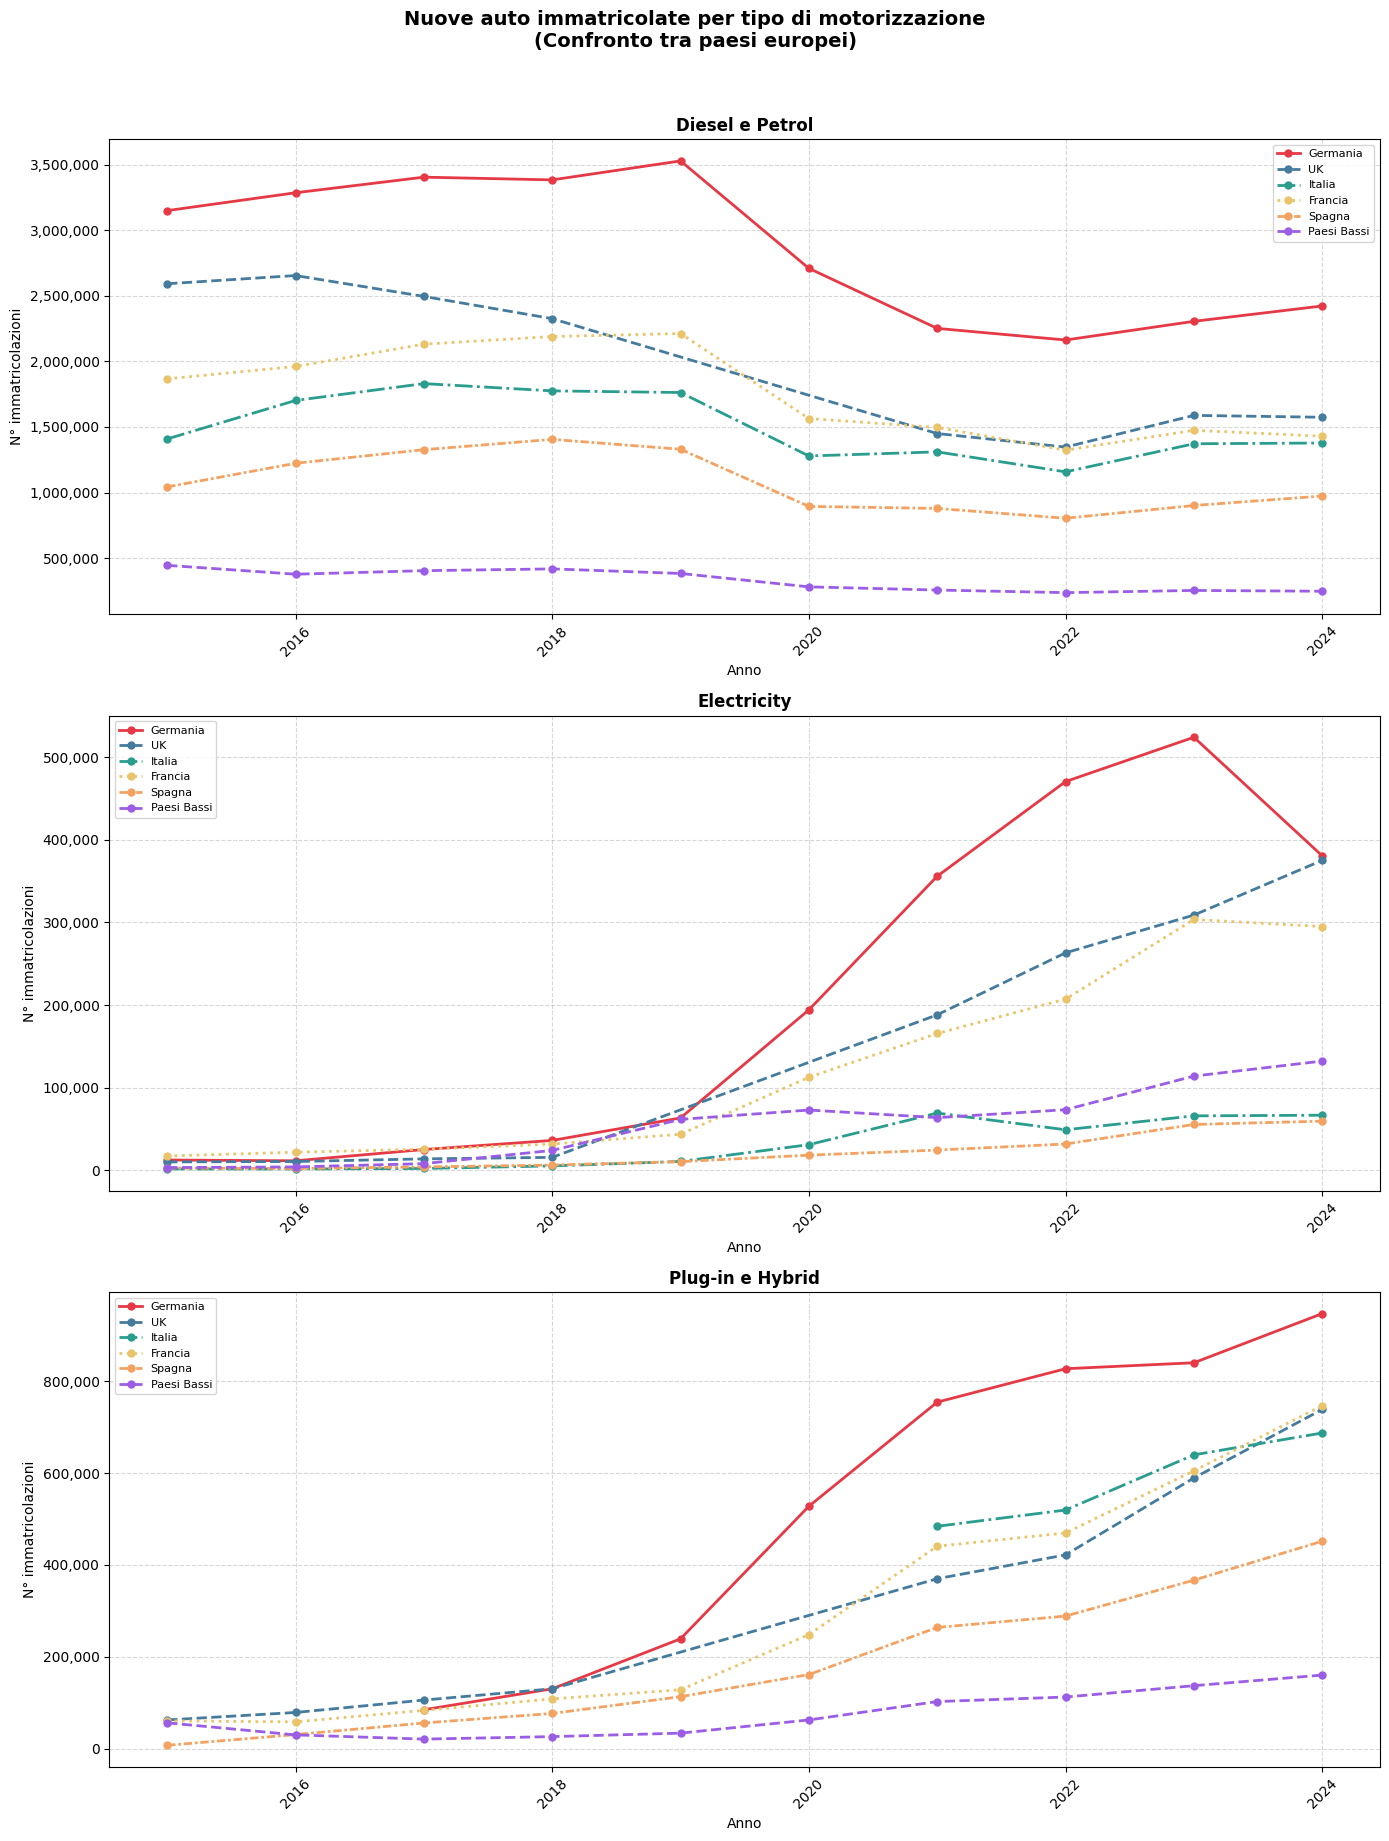

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Carica dati ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/csv/confronto_combustibili_europa.csv')

# ── Paesi di interesse ───────────────────────────────────────────────────────
countries = {
    'Germany':        'Germania',
    'United Kingdom': 'UK',
    'Italy':          'Italia',
    'France':         'Francia',
    'Spain':          'Spagna',
    'Netherlands':    'Paesi Bassi',
}

# ── Categorizzazione ─────────────────────────────────────────────────────────
def categorize(val):
    if pd.isna(val):
        return None
    v = str(val).lower().strip()
    if 'electric' in v and 'plug' not in v and 'hybrid' not in v:
        return 'Electricity'
    elif 'plug-in' in v or 'hybrid' in v:
        return 'Plug-in e Hybrid'
    elif 'diesel' in v or 'petrol' in v:
        return 'Diesel e Petrol'
    return None

df['Category'] = df['Motor energy'].apply(categorize)
df = df[df['Category'].notna()]

# ── Filtra paesi ─────────────────────────────────────────────────────────────
df = df[df['Geopolitical entity (reporting)'].isin(countries.keys())]
df['Country'] = df['Geopolitical entity (reporting)'].map(countries)

# ── Aggrega per anno, paese, categoria ───────────────────────────────────────
grouped = (df.groupby(['TIME_PERIOD', 'Country', 'Category'])['OBS_VALUE']
             .sum()
             .reset_index())

categories = ['Diesel e Petrol', 'Electricity', 'Plug-in e Hybrid']
colors = {
    'Germania':   '#E63946',
    'UK':         '#457B9D',
    'Italia':     '#2A9D8F',
    'Francia':    '#E9C46A',
    'Spagna':     '#F4A261',
    'Paesi Bassi':'#9B5DE5',
}
linestyles = {
    'Germania':   '-',
    'UK':         '--',
    'Italia':     '-.',
    'Francia':    ':',
    'Spagna':     (0, (3, 1, 1, 1)),
    'Paesi Bassi':'--',
}

# ── Grafico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharey=False)
fig.suptitle('Nuove auto immatricolate per tipo di motorizzazione\n(Confronto tra paesi europei)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, cat in zip(axes, categories):
    data_cat = grouped[grouped['Category'] == cat]
    for country in countries.values():
        data_c = data_cat[data_cat['Country'] == country].sort_values('TIME_PERIOD')
        if data_c.empty:
            continue
        ax.plot(data_c['TIME_PERIOD'], data_c['OBS_VALUE'],
                label=country,
                color=colors[country],
                linestyle=linestyles[country],
                linewidth=2,
                marker='o', markersize=5)

    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('N° immatricolazioni')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()